In [ ]:
# Experiment Peer-set Growth and Monotonicity Diagnostics
# Motivation 
# A robust uniqueness measure should not increase when we enlarge the available peer set under fixed budget and consistent modeling assumptions. This notebook contrasts non-additive and additive kernels under peer-set growth.  

# $$
# U_t^{\mathrm{ker}}(p;\Lambda)=\mathbb{E}[|Y_t-h^*_{\Lambda,p}(\Phi_{-t}^{(p)})|].
# $$
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "figure.figsize": (7, 4.5),
    "figure.dpi": 150,
    "mathtext.fontset": "dejavuserif"
})

from pathlib import Path
import numpy as np
import pandas as pd
art_dir = Path('../results/artifacts').resolve()
art_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(Path('../results/tables/exp4_monotonicity.csv').resolve())
df.head()

,peer_count,budget_alpha,budget_proxy,non_additive_kernel_pier,additive_kernel_pier_raw,additive_kernel_pier,non_additive_violation_step,additive_raw_violation_step,fit_size,eval_size,honesty_fit_size,honesty_eval_size,gamma_nonadd,gamma_add,seed
0,1,0.02,50.0,0.099945,0.100052,0.100052,0,0,280,320,280,320,0.45,1.0,7
1,2,0.02,50.0,0.059441,0.068973,0.068973,0,0,280,320,280,320,0.45,1.0,7
2,3,0.02,50.0,0.048997,0.061711,0.061711,0,0,280,320,280,320,0.45,1.0,7
3,4,0.02,50.0,0.034694,0.042732,0.042732,0,0,280,320,280,320,0.45,1.0,7
4,5,0.02,50.0,0.031663,0.041440,0.041440,0,0,280,320,280,320,0.45,1.0,7


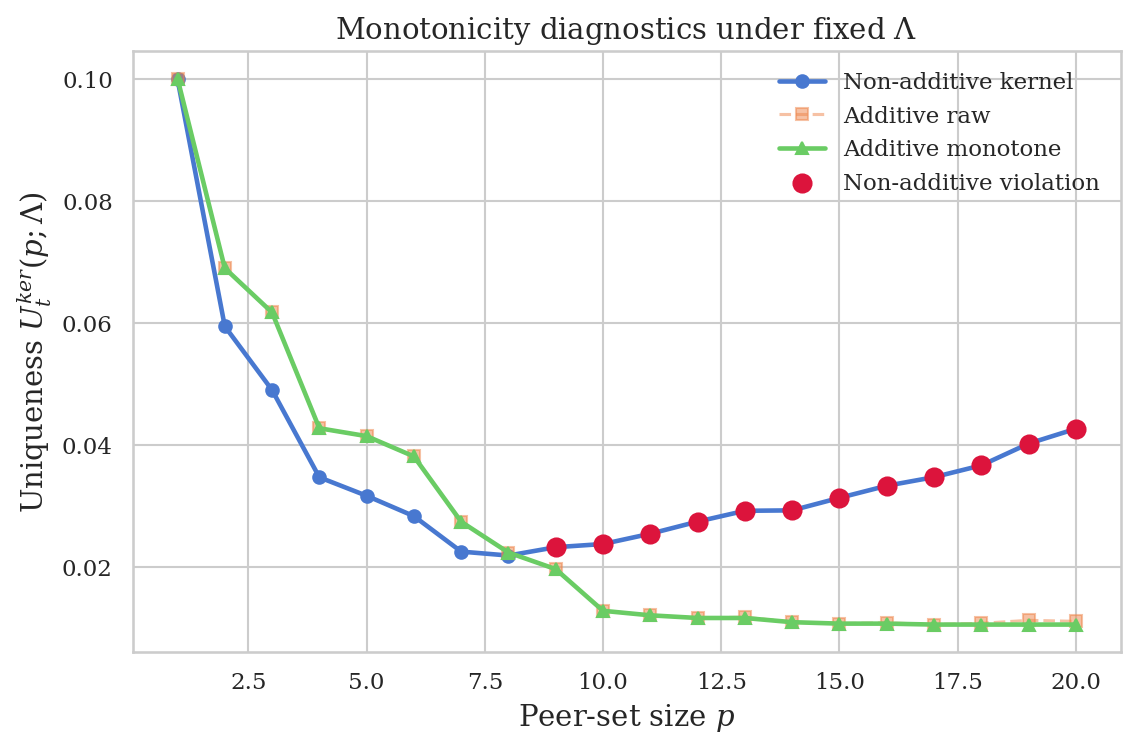

In [ ]:
# Main monotonicity curve with violation markers
#This figure is the primary diagnostic: additive trend should be non-increasing while non-additive may exhibit reversals.

fig, ax = plt.subplots(figsize=(8.5, 5.2))
x = df['peer_count'].to_numpy()
ax.plot(x, df['non_additive_kernel_pier'], marker='o', linewidth=2.2, label='Non-additive kernel')
ax.plot(x, df['additive_kernel_pier_raw'], marker='s', linestyle='--', alpha=0.5, label='Additive raw')
ax.plot(x, df['additive_kernel_pier'], marker='^', linewidth=2.2, label='Additive monotone')
viol = df[df['non_additive_violation_step'] == 1]
if len(viol) > 0:
    ax.scatter(viol['peer_count'], viol['non_additive_kernel_pier'], color='crimson', s=75, zorder=5, label='Non-additive violation')
ax.set_xlabel(r'Peer-set size $p$')
ax.set_ylabel(r'Uniqueness $U_t^{ker}(p;\Lambda)$')
ax.set_title(r'Monotonicity diagnostics under fixed $\Lambda$')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp4_main_monotonicity_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()


#补全一个convex hull的对照。

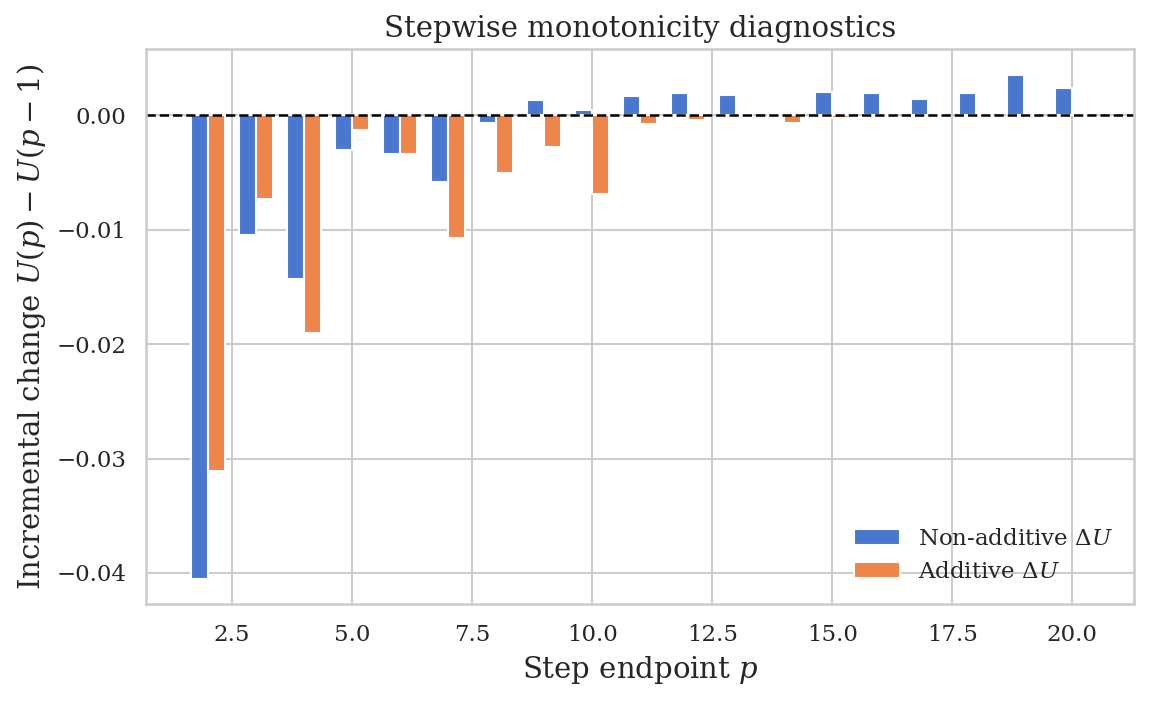

In [ ]:
#Incremental slope analysis identifies where monotonicity breaks
#First differences make violation locations explicit and separate gradual drift from abrupt failures.

d_nonadd = np.r_[np.nan, np.diff(df['non_additive_kernel_pier'].to_numpy())]
d_add = np.r_[np.nan, np.diff(df['additive_kernel_pier'].to_numpy())]
step_df = pd.DataFrame({'peer_count': df['peer_count'], 'nonadd_delta': d_nonadd, 'add_delta': d_add}).dropna()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(step_df['peer_count'] - 0.18, step_df['nonadd_delta'], width=0.35, label='Non-additive $\Delta U$')
ax.bar(step_df['peer_count'] + 0.18, step_df['add_delta'], width=0.35, label='Additive $\Delta U$')
ax.axhline(0.0, linestyle='--', color='black', linewidth=1.2)
ax.set_xlabel(r'Step endpoint $p$')
ax.set_ylabel(r'Incremental change $U(p)-U(p-1)$')
ax.set_title('Stepwise monotonicity diagnostics')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp4_stepwise_delta_bars.pdf', format='pdf', bbox_inches='tight')
plt.show()

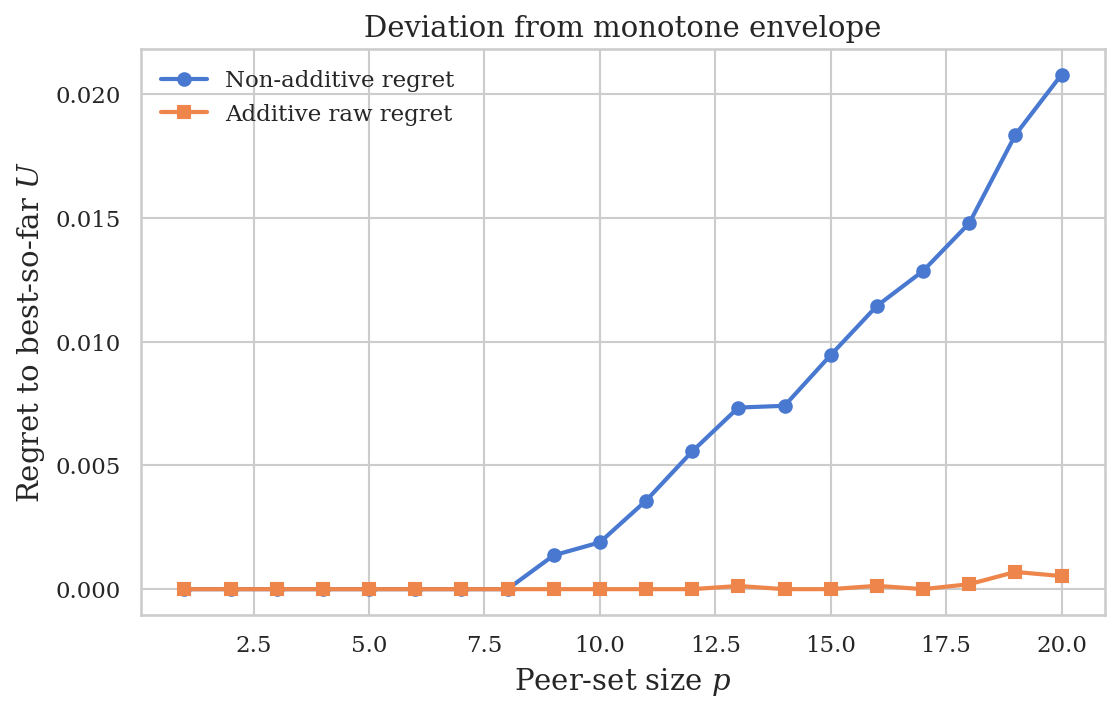

In [ ]:
#Regret-style visualization relative to best achieved value
#Regret to the best-so-far level highlights how strongly each method deviates from monotone improvement.
nonadd = df['non_additive_kernel_pier'].to_numpy()
addraw = df['additive_kernel_pier_raw'].to_numpy()
reg_nonadd = nonadd - np.minimum.accumulate(nonadd)
reg_add = addraw - np.minimum.accumulate(addraw)

fig, ax = plt.subplots(figsize=(8.3, 4.9))
ax.plot(df['peer_count'], reg_nonadd, marker='o', linewidth=2.0, label='Non-additive regret')
ax.plot(df['peer_count'], reg_add, marker='s', linewidth=2.0, label='Additive raw regret')
ax.set_xlabel(r'Peer-set size $p$')
ax.set_ylabel(r'Regret to best-so-far $U$')
ax.set_title('Deviation from monotone envelope')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp4_regret_to_monotone_envelope.pdf', format='pdf', bbox_inches='tight')
plt.show()

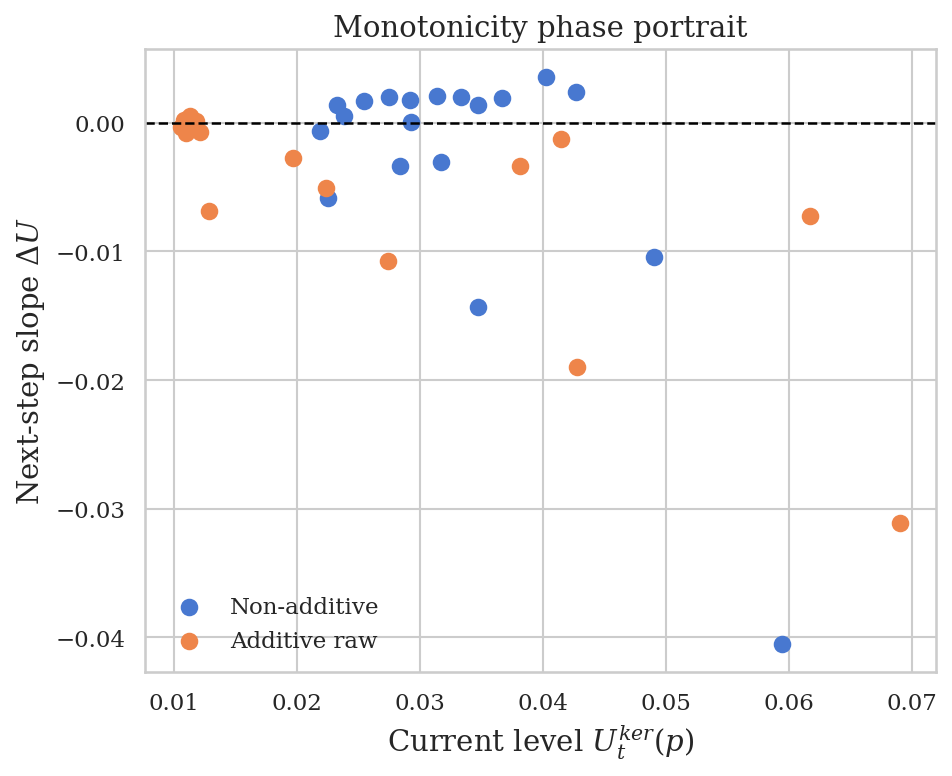

In [ ]:
# Phase portrait (level vs slope)
#A phase portrait captures dynamics of each method and visually separates stable descent from unstable regions.
phase = pd.DataFrame({
    'peer_count': df['peer_count'],
    'nonadd_level': df['non_additive_kernel_pier'],
    'add_level': df['additive_kernel_pier_raw'],
    'nonadd_delta': np.r_[np.nan, np.diff(df['non_additive_kernel_pier'].to_numpy())],
    'add_delta': np.r_[np.nan, np.diff(df['additive_kernel_pier_raw'].to_numpy())]
}).dropna()

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.scatter(phase['nonadd_level'], phase['nonadd_delta'], s=55, label='Non-additive')
ax.scatter(phase['add_level'], phase['add_delta'], s=55, label='Additive raw')
ax.axhline(0.0, linestyle='--', color='black', linewidth=1.2)
ax.set_xlabel(r'Current level $U_t^{ker}(p)$')
ax.set_ylabel(r'Next-step slope $\Delta U$')
ax.set_title('Monotonicity phase portrait')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp4_phase_portrait_level_vs_slope.pdf', format='pdf', bbox_inches='tight')
plt.show()